| 項目 | 期待リターン | リスク（分散係数） |
|------|-------------|------------------|
| 資産A | 10% | 0.20 |
| 資産B | 5% | 0.10 |
| 説明 | 平均的にどれくらい増えるか | 価格変動の大きさ（不安定さ） |

# 投資の多目的最適化（目的関数）

## 目的関数の定義

この問題では、投資割合 \(x\)（資産Aへの投資比率）を最適化する。

---

## 目的1：リターン（最大化）

リターンは以下で定義される：

\[
R(x) = 0.10x + 0.05(1 - x)
\]

pymooでは最小化問題として扱うため：

\[
f_1(x) = -R(x)
\]

---

## 目的2：リスク（最小化）

リスクは分散の簡略モデルとして定義：

\[
f_2(x) = 0.20x^2 + 0.10(1 - x)^2
\]

---

## 最適化問題のまとめ

\[
\min \; f_1(x), \quad \min \; f_2(x)
\]

制約条件：

\[
0 \le x \le 1
\]

---

## 意味

- \(f_1\)：リターンを大きくする（負の値として最小化）
- \(f_2\)：リスクを小さくする
- 2つはトレードオフ関係にある

In [7]:
import numpy as np
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

re=[0.1,0.05]
ri=[0.2,0.1]
# 自作の問題クラス
class MyProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=1,       # 設計変数の数
            n_obj=2,       # 目的関数の数
            xl=0,   # 下限値
            xu=1    # 上限値
        )

    def _evaluate(self, x, out, *args, **kwargs):
        # 目的関数1：原点から近いほど小さい
        f1 = -(re[0]*x+re[1]*(1-x))
        # 目的関数2：(1, 0)から近いほど小さい
        f2 = ri[0]*x**2 + ri[1]*(1-x)**2
        out["F"] = np.column_stack([f1, f2])



n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     67 |             - |             -
     2 |      200 |    100 |  0.0046628500 |             f
     3 |      300 |    100 |  0.0119175560 |         ideal
     4 |      400 |    100 |  0.0062895401 |         ideal
     5 |      500 |    100 |  0.0021314703 |             f
     6 |      600 |    100 |  0.0061279793 |         ideal
     7 |      700 |    100 |  0.0103653434 |         nadir
     8 |      800 |    100 |  0.0039636914 |         ideal
     9 |      900 |    100 |  0.0026206749 |             f
    10 |     1000 |    100 |  0.0048323184 |         nadir
    11 |     1100 |    100 |  0.0022897011 |             f
    12 |     1200 |    100 |  0.0044369717 |             f
    13 |     1300 |    100 |  0.0021090966 |             f
    14 |     1400 |    100 |  0.0032953244 |             f
    15 |     1500 |    100 |  0.0023291147 |             f
    16 |     1600 |    100 |  0.0035464357 |            

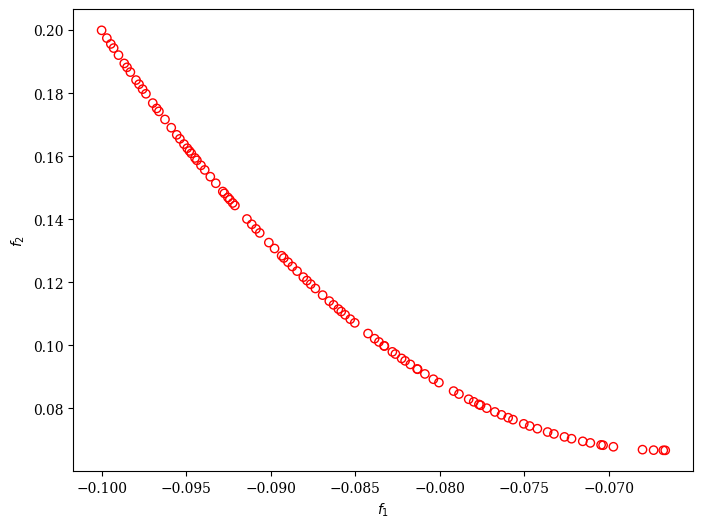

In [9]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
import pandas as pd

problem = MyProblem()
algorithm = NSGA2(pop_size=100)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 200),
    seed=1,
    verbose=True
)

# 結果の確認
print(f"パレート最適解の数: {len(res.F)}")

df = pd.DataFrame({
    "資産A比率": res.X[:, 0],
    "資産B比率": 1 - res.X[:, 0],
    "リターン": -res.F[:, 0],
    "リスク": res.F[:, 1],
})
print(df.head(10).to_string(index=False))

# パレートフロントの描画
plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

## 実際の投資データで最適化を行ってみる

# 資産クラス別リスク・リターン特性一覧（国内主要インデックス・コモディティ）

本データは、日本の投資信託（eMAXIS Slimシリーズ等）が連動を目指す代表的な指数、および金（ゴールド）の過去の長期実績に基づいた推計値です。

| 資産クラス | 具体的な投資先の例 | 期待リターン (年率) | リスク (標準偏差) | 特徴 |
| :--- | :--- | :--- | :--- | :--- |
| **1. 日本株式** | TOPIX（東証株価指数） | 5.0% | 18.0% | 国内企業の成長に投資。為替リスクがない。 |
| **2. 先進国株式** | MSCI KOKUSAI | 8.5% | 19.5% | 米国中心の主要先進国。為替変動の影響を受ける。 |
| **3. 全世界株式** | MSCI ACWI（オルカン） | 7.5% | 18.5% | 世界の株式に分散。地域分散によりリスクを緩和。 |
| **4. 米国株式** | S&P500 | 9.5% | 20.0% | 高い成長性だが、1カ国集中と為替のリスクがある。 |
| **5. 新興国株式** | MSCI エマージング | 6.5% | 23.0% | 成長性は高いが、政治や通貨の変動が最も激しい。 |
| **6. 国内債券** | NOMURA-BPI 総合 | 0.5% | 3.0% | 非常に安定。守りの資産だがインフレには弱い。 |
| **7. 先進国債券** | FTSE 世界国債指数 | 2.5% | 9.0% | 日本より高金利だが、為替による変動がある。 |
| **8. 国内REIT** | 東証REIT指数 | 4.5% | 16.0% | 日本国内の不動産に投資。株式とは異なる値動き。 |
| **9. 先進国REIT** | S&P 先進国REIT | 6.5% | 19.0% | 世界の商業ビル等。株式に近い価格変動特性。 |
| **10. 金 (Gold)** | LBMA 金価格 | 5.5% | 15.0% | 「有事の金」。株価急落時やインフレ時に強い。 |

---

In [13]:
re = np.array([0.05, 0.085, 0.075, 0.095, 0.065, 0.005, 0.025, 0.045, 0.065, 0.055]) #
ri = np.array([0.18, 0.195, 0.185, 0.20, 0.23, 0.03, 0.09, 0.16, 0.19, 0.15])

In [57]:
import numpy as np
from pymoo.core.problem import Problem

class MyProblem(Problem):
    def __init__(self):
        super().__init__(
            n_var=10,    # 設計変数の数：10個の資産の比率
            n_obj=2,     # 目的関数の数：リターン最大化とリスク最小化
            n_constr=1,  # 制約条件の数：合計比率 = 100%
            xl=0.0,      # 各資産の最小比率（0%）
            xu=1.0       # 各資産の最大比率（100%）
        )

    def _evaluate(self, x, out, *args, **kwargs):
        # x は (個体数, 10) の行列

        # 目的関数1：ポートフォリオ全体の期待リターン（のマイナス）
        # 各資産の比率 * 期待リターンの合計
        f1 = -np.sum(x * re, axis=1)

        # 目的関数2：ポートフォリオ全体の推定リスク（分散）
        # 各資産の比率の2乗 * リスクの2乗（簡易モデル：相関なしと仮定）
        f2 = np.sum((x**2) * (ri**2), axis=1)

        # 制約条件：合計比率が1.0であること
        # pymooでは「g(x) <= 0」の形式で記述するため、abs(sum - 1) = 0 を目指す
        g1 = np.abs(np.sum(x, axis=1) - 1.0) - 0.1

        out["F"] = np.column_stack([f1, f2])
        out["G"] = g1

### NSGA-III

In [58]:
# 最適化の実行
problem   = MyProblem()
algorithm = NSGA2(pop_size=100)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 300),
    seed=42,
    verbose=False
)

パレート最適解の数: 100
    リターン      リスク
0.085797 0.008968
0.035238 0.001173
0.042732 0.001581
0.045183 0.001757
0.065847 0.003884
0.083660 0.008409
0.083519 0.007993
0.039336 0.001375
0.064812 0.003700
0.073317 0.004900


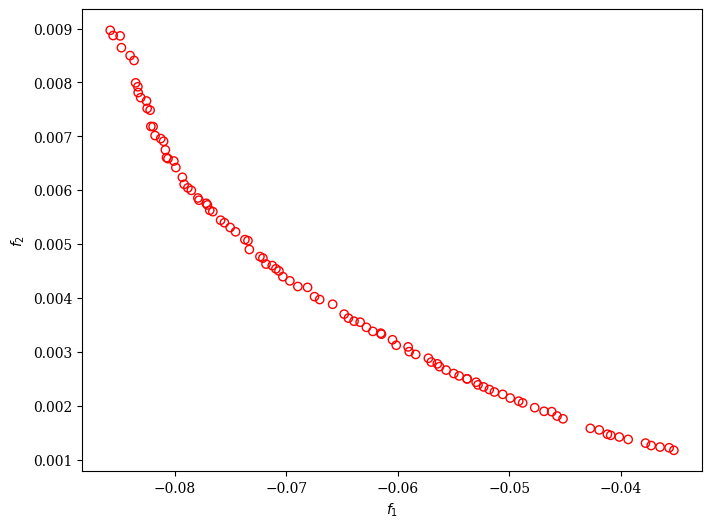

In [67]:
##結果の表示
print(f"パレート最適解の数: {len(res.F)}")

amout=1000000

df = pd.DataFrame({
    "リターン": -res.F[:, 0],
    "リスク": res.F[:, 1],
})


mean_return=np.mean(-res.F[:, 0])
mean_risk=np.std(res.F[:, 1])



print(df.head(10).to_string(index=False))

# パレートフロントの描画
plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

In [69]:
# 2. 100万円あたりの金額に換算
amount = 1000000
expected_gain = amount * mean_return
risk_amount = amount * mean_risk

# 3. 増減の範囲を算出
plus_side = expected_gain + risk_amount
minus_side = expected_gain - risk_amount

print(f"【投資額 {amount/10000:,.0f}万円 の年間収益予測】")
print(f"■ 平均的な期待収益： +{expected_gain:,.0f}円")
print(f"■ 収益の変動幅（約68%の確率でこの範囲に収まります）")
print(f"　 良い場合： +{plus_side:,.0f}円")
print(f"　 悪い場合： {minus_side:,.0f}円")

【投資額 100万円 の年間収益予測】
■ 平均的な期待収益： +65,284円
■ 収益の変動幅（約68%の確率でこの範囲に収まります）
　 良い場合： +67,508円
　 悪い場合： 63,060円


In [63]:
import pandas as pd
import numpy as np

# 資産名の定義
asset_names = [
    "日本株式", "先進国株式", "全世界株式", "米国株式", "新興国株式",
    "国内債券", "先進国債券", "国内REIT", "先進国REIT", "金(Gold)"
]

if res.X is not None:
    # 全てのパレート解の比率をデータフレーム化
    # 正規化後の比率（res.X）を使用
    df_all_weights = pd.DataFrame(res.X, columns=asset_names)
    df_all_weights['Expected Return'] = -res.F[:, 0] # 期待リターン
    df_all_weights['Risk (Variance)'] = res.F[:, 1]  # リスク（分散）

    # 代表的な3つのポイントのインデックスを取得
    indices = {
        "--- 【安定重視】リスク最小 (Min Risk) ---": np.argmin(res.F[:, 1]),
        "--- 【バランス】中間地点 (Median) ---": len(res.F) // 2,
        "--- 【積極重視】リターン最大 (Max Return) ---": np.argmax(-res.F[:, 0])
    }

    print(f"Total Pareto Solutions found: {len(res.F)}")

    for title, idx in indices.items():
        print(f"\n{title}")
        row = df_all_weights.iloc[idx]

        # 投資比率の表示（1%以上の資産のみ表示すると見やすくなります）
        for name in asset_names:
            weight = row[name] * 100
            if weight > 0.1: # 0.1%以上の配分がある資産を表示
                print(f"  {name}: {weight:.2f}%")

        print(f"  >> Expected Return: {row['Expected Return']*100:.2f}%")
        print(f"  >> Risk (Variance): {row['Risk (Variance)']*100:.2f}%")

    # 全ての解を俯瞰するための要約統計
    print("\n--- 全パレート解の統計値 ---")
    print(df_all_weights[['Expected Return', 'Risk (Variance)']].describe().loc[['min', 'max', 'mean']])

else:
    print("解が見つかりませんでした。制約条件または正規化処理を確認してください。")

Total Pareto Solutions found: 100

--- 【安定重視】リスク最小 (Min Risk) ---
  日本株式: 6.58%
  先進国株式: 6.09%
  全世界株式: 6.36%
  米国株式: 3.25%
  新興国株式: 4.84%
  国内債券: 30.52%
  先進国債券: 12.93%
  国内REIT: 5.76%
  先進国REIT: 6.42%
  金(Gold): 7.71%
  >> Expected Return: 3.52%
  >> Risk (Variance): 0.12%

--- 【バランス】中間地点 (Median) ---
  日本株式: 8.92%
  先進国株式: 18.30%
  全世界株式: 18.04%
  米国株式: 22.00%
  新興国株式: 8.44%
  国内REIT: 7.86%
  先進国REIT: 12.84%
  金(Gold): 13.35%
  >> Expected Return: 7.92%
  >> Risk (Variance): 0.61%

--- 【積極重視】リターン最大 (Max Return) ---
  日本株式: 0.19%
  先進国株式: 29.42%
  全世界株式: 17.32%
  米国株式: 30.22%
  新興国株式: 8.28%
  国内債券: 0.28%
  先進国債券: 1.21%
  国内REIT: 1.77%
  先進国REIT: 8.13%
  金(Gold): 13.11%
  >> Expected Return: 8.58%
  >> Risk (Variance): 0.90%

--- 全パレート解の統計値 ---
      Expected Return  Risk (Variance)
min          0.035238         0.001173
max          0.085797         0.008968
mean         0.065284         0.004385


【投資額 100万円 の年間収益予測】
■ 平均的な期待収益： +65,284円
■ 収益の変動幅（約68%の確率でこの範囲に収まります）
　 良い場合： +67,508円
　 悪い場合： 63,060円


### SPEA2

In [79]:
from pymoo.algorithms.moo.spea2 import SPEA2

# SPEA2 を使用（numba不要）
algorithm = SPEA2(pop_size=100)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 300),
    seed=42,
    verbose=False
)

/Users/asamigentoku/Desktop/my-lab/.venv/lib/python3.13/site-packages/pymoo/algorithms/moo/spea2.py:62: RuntimeWarning: invalid value encountered in divide
  _F = (F - ideal) / (nadir - ideal)


パレート最適解の数: 100
    リターン      リスク
0.082417 0.007214
0.081159 0.006820
0.071116 0.004570
0.038386 0.001323
0.060763 0.003215
0.083887 0.007903
0.051142 0.002241
0.070931 0.004485
0.076175 0.005455
0.035533 0.001182


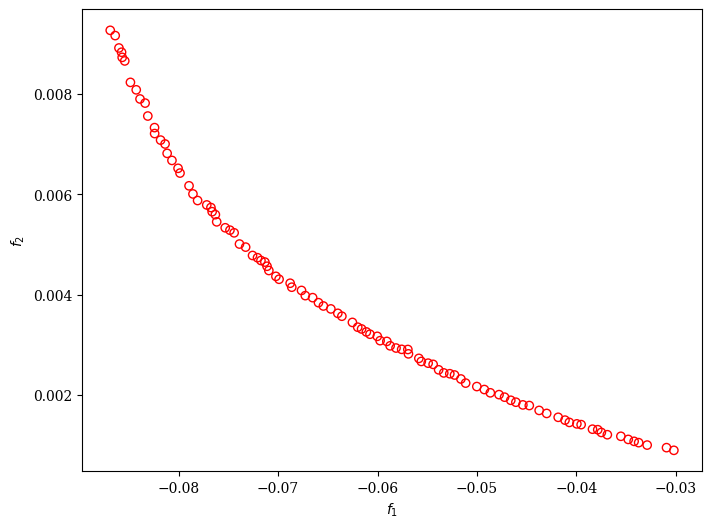

In [80]:
##結果の表示
print(f"パレート最適解の数: {len(res.F)}")

amout=1000000

df = pd.DataFrame({
    "リターン": -res.F[:, 0],
    "リスク": res.F[:, 1],
})


mean_return=np.mean(-res.F[:, 0])
mean_risk=np.std(res.F[:, 1])



print(df.head(10).to_string(index=False))

# パレートフロントの描画
plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.show()

In [84]:
# 2. 100万円あたりの金額に換算
amount = 1000000
expected_gain = amount * mean_return
risk_amount = amount * mean_risk

# 3. 増減の範囲を算出
plus_side = expected_gain + risk_amount
minus_side = expected_gain - risk_amount

print(f"【投資額 {amount/10000:,.0f}万円 の年間収益予測】")
print(f"■ 平均的な期待収益： +{expected_gain:,.0f}円")
print(f"■ 収益の変動幅（約68%の確率でこの範囲に収まります）")
print(f"　 良い場合： +{plus_side:,.0f}円")
print(f"　 悪い場合： {minus_side:,.0f}円")

【投資額 100万円 の年間収益予測】
■ 平均的な期待収益： +62,177円
■ 収益の変動幅（約68%の確率でこの範囲に収まります）
　 良い場合： +64,482円
　 悪い場合： 59,872円
